# Learning Physics from the Machines

Machine learning models can sometimes find useful structure before humans know how to name it. The goal of this notebook is to study that situation scientifically: when a model performs well, how can we turn its internal strategy into a human-readable insight?

In [1]:
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
    plt.style.use('seaborn-v0_8-whitegrid')
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False

    class _FakeArtist:
        def __getattr__(self, name):
            if name.startswith('__'):
                raise AttributeError(name)
            def _no_op(*args, **kwargs):
                return self
            return _no_op

    class _FakeFigure(_FakeArtist):
        pass

    class _FakePlt(_FakeArtist):
        style = _FakeArtist()

        def subplots(self, nrows=1, ncols=1, figsize=None):
            fig = _FakeFigure()
            axes = np.array([_FakeArtist() for _ in range(nrows * ncols)], dtype=object).reshape(nrows, ncols)
            if nrows == 1 and ncols == 1:
                axes = axes[0, 0]
            elif nrows == 1 or ncols == 1:
                axes = axes.ravel()
            return fig, axes

        def show(self):
            print('matplotlib is not installed; skipping plot display.')

    plt = _FakePlt()
    print('matplotlib is not installed in this Python environment. Numeric examples will run, but plots are skipped.')

rng = np.random.default_rng(498)


## <span style="color:Orange">Overview</span>

Scientific machine learning is often advertised as a way to make predictions. In this lecture we focus on a more ambitious goal:

> Can a trained model teach us a new variable, symmetry, scaling law, approximation, or mechanism?

There are many levels of "learning from a machine":

1. <span style="color:Violet">Rediscovery</span>: the model finds a known human concept, such as jet invariant mass or an inverse-square force law. This is a calibration test for interpretability.
2. <span style="color:Violet">Compression</span>: the model suggests a simpler coordinate system, latent variable, or effective description.
3. <span style="color:Violet">Extension</span>: the model points toward a relation that was not already part of the standard human feature set.
4. <span style="color:Violet">Discovery</span>: the model proposes a robust, testable, human-understandable law that survives independent validation.

The last category is rare. The useful day-to-day workflow is usually a loop: train a flexible model, interrogate it, distill a simpler description, and then test the distilled idea as physics.


## <span style="color:Orange">The Human-in-the-Loop Discovery Cycle</span>

A practical discovery workflow looks like this:

1. Train a high-capacity model on low-level data.
2. Check that it generalizes to data not used in training.
3. Ask what information the model uses: feature importance, saliency, counterfactuals, latent-space probes, or surrogate models.
4. Translate the behavior into a candidate scientific object: an observable, symmetry, scaling variable, equation, or mechanism.
5. Validate the candidate object with ablations, controlled simulations, independent data, and uncertainty estimates.
6. Only then promote the object from "the model uses this" to "this is physics."

This distinction matters. A network can exploit detector artifacts, simulation shortcuts, or selection biases. Learning from the machine is not the same as trusting the machine.


## <span style="color:Orange">Motivating Examples from Physics</span>

| Domain | What the machine learns | What humans can try to extract |
|---|---|---|
| Collider physics | A top tagger separates top jets from QCD jets using low-level jet information | Known observables such as invariant mass, plus subtler substructure or detector-sensitive information |
| Jet images and particle clouds | Spatial energy-flow patterns in jets | Color flow, prong structure, radiation patterns, and new jet observables |
| Symbolic regression | A compact equation that fits numerical data | A candidate law, conservation rule, or scaling relation |
| Cosmology simulations | Relations inside high-dimensional structure-formation data | Analytic approximations for halo or environmental quantities |
| Condensed matter | Order parameters or phase boundaries from microscopic configurations | Candidate order parameters, critical exponents, and universality classes |

The theme is not that ML replaces theory. The theme is that ML can function like a microscope for patterns, after which physicists still have to name, simplify, and stress-test what was seen.


In [2]:
def auc_score(y_true, score):
    """A small dependency-free AUC implementation."""
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    order = np.argsort(score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(score) + 1)
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    return (np.sum(ranks[y_true == 1]) - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def histogram_likelihood_score(x_train, y_train, x_eval, bins=35):
    """Fit a 1D histogram likelihood ratio p(x|signal)/p(x|background)."""
    edges = np.quantile(x_train, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 4:
        return np.zeros_like(x_eval, dtype=float)

    sig_counts, _ = np.histogram(x_train[y_train == 1], bins=edges)
    bkg_counts, _ = np.histogram(x_train[y_train == 0], bins=edges)
    log_lr = np.log((sig_counts + 1.0) / (bkg_counts + 1.0))

    idx = np.searchsorted(edges, x_eval, side='right') - 1
    idx = np.clip(idx, 0, len(log_lr) - 1)
    return log_lr[idx]


def invariant_mass(E, px, py, pz):
    m2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(np.maximum(m2, 0.0))


## <span style="color:Orange">Case Study 1: Rediscovering Jet Invariant Mass</span>

In collider physics, a common benchmark for interpretability is whether a model trained on low-level collision information rediscovers variables already known to physicists.

For a four-vector $(E, p_x, p_y, p_z)$, the invariant mass is

$$ \Large
 m^2 = E^2 - p_x^2 - p_y^2 - p_z^2.
$$

This is not an arbitrary engineered feature. It is the Lorentz-invariant quantity that produces resonance peaks when a heavy particle decays into visible particles. In the real top-tagging interpretability study mentioned in the prompt, XAI methods and latent-space probes were used to understand what top taggers learn. Here we build a small toy version: signal events contain a resonance near the top-quark mass, while background events have a broad continuum.


In [3]:
def make_resonance_dataset(n_events=5000, signal_mass=173.0, signal_width=13.0):
    n_sig = n_events // 2
    n_bkg = n_events - n_sig

    y = np.r_[np.ones(n_sig, dtype=int), np.zeros(n_bkg, dtype=int)]

    # Signal has a resonance; background is broad and structureless in this toy model.
    mass = np.r_[
        rng.normal(signal_mass, signal_width, size=n_sig),
        rng.uniform(40.0, 280.0, size=n_bkg),
    ]
    mass = np.clip(mass, 5.0, None)

    pt = np.r_[
        rng.gamma(shape=5.0, scale=45.0, size=n_sig),
        rng.gamma(shape=4.0, scale=50.0, size=n_bkg),
    ]
    eta = rng.uniform(-2.2, 2.2, size=n_events)
    phi = rng.uniform(-np.pi, np.pi, size=n_events)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = np.sqrt(px**2 + py**2 + pz**2 + mass**2)

    shuffle = rng.permutation(n_events)
    return {
        'E': E[shuffle],
        'px': px[shuffle],
        'py': py[shuffle],
        'pz': pz[shuffle],
        'pT': pt[shuffle],
        'eta': eta[shuffle],
        'y': y[shuffle],
    }


data = make_resonance_dataset()
y = data['y']

observables = {
    'E': data['E'],
    'px': data['px'],
    'py': data['py'],
    'pz': data['pz'],
    'pT': data['pT'],
    '|eta|': np.abs(data['eta']),
    'm = sqrt(E^2 - p^2)': invariant_mass(data['E'], data['px'], data['py'], data['pz']),
    'm^2 = E^2 - p^2': data['E']**2 - data['px']**2 - data['py']**2 - data['pz']**2,
}

n_train = 3500
train = np.arange(n_train)
test = np.arange(n_train, len(y))

results = []
for name, values in observables.items():
    score = histogram_likelihood_score(values[train], y[train], values[test])
    results.append((name, auc_score(y[test], score)))

results = sorted(results, key=lambda item: item[1], reverse=True)
print('One-dimensional likelihood-ratio observables ranked by test AUC:')
for name, auc in results:
    print(f'{name:24s}  AUC = {auc:.3f}')


One-dimensional likelihood-ratio observables ranked by test AUC:
m = sqrt(E^2 - p^2)       AUC = 0.912
m^2 = E^2 - p^2           AUC = 0.912
E                         AUC = 0.540
pT                        AUC = 0.539
px                        AUC = 0.534
|eta|                     AUC = 0.515
py                        AUC = 0.505
pz                        AUC = 0.484


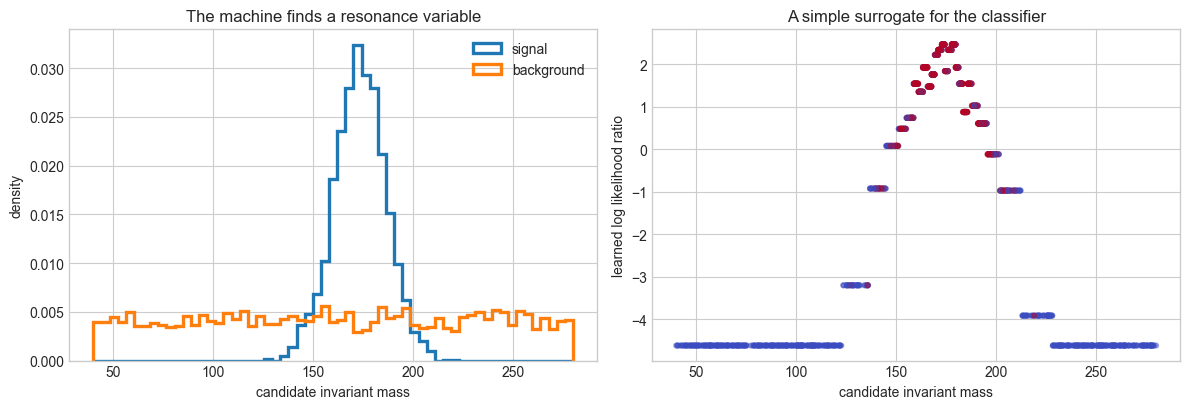

In [4]:
mass = observables['m = sqrt(E^2 - p^2)']
score_mass = histogram_likelihood_score(mass[train], y[train], mass[test])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

bins = np.linspace(40, 280, 60)
axes[0].hist(mass[y == 1], bins=bins, histtype='step', linewidth=2.4, density=True, label='signal')
axes[0].hist(mass[y == 0], bins=bins, histtype='step', linewidth=2.4, density=True, label='background')
axes[0].set_xlabel('candidate invariant mass')
axes[0].set_ylabel('density')
axes[0].set_title('The machine finds a resonance variable')
axes[0].legend()

axes[1].scatter(mass[test], score_mass, s=12, alpha=0.45, c=y[test], cmap='coolwarm')
axes[1].set_xlabel('candidate invariant mass')
axes[1].set_ylabel('learned log likelihood ratio')
axes[1].set_title('A simple surrogate for the classifier')

plt.tight_layout()
plt.show()


### <span style="color:LightGreen">What Did We Learn?</span>

The machine did not merely find a numerical separator. When we interrogated simple candidate observables, the best one was the Lorentz-invariant mass. That is a rediscovery: it tells us our interpretability method can recover a concept that humans already trust.

In a real analysis, this is only the beginning. If the model performs better than invariant mass alone, the next question is: what is the extra information? Possibilities include radiation patterns, color flow, particle multiplicities, detector response, pileup sensitivity, or simulation-specific artifacts.

**Exercise 1:** Change the signal width in `make_resonance_dataset`. When does invariant mass stop being an obvious discovery?

**Exercise 2:** Add a nuisance variable that differs between signal and background but has no physics meaning. Can the ranking procedure be fooled?


## <span style="color:Orange">Case Study 2: Distilling a Scaling Variable</span>

Machines can also teach us by suggesting a better coordinate. In critical phenomena, the raw variables might be temperature $T$ and system size $L$, but the revealing variable is often a dimensionless scaling combination such as

$$ \Large
 z = (T - T_c)L^{1/\nu}.
$$

If the correct exponent $\nu$ is used, measurements from different system sizes collapse onto a common curve. In this toy example, we generate data from a hidden finite-size scaling law and then ask a machine-like search to find the exponent that produces the best collapse.


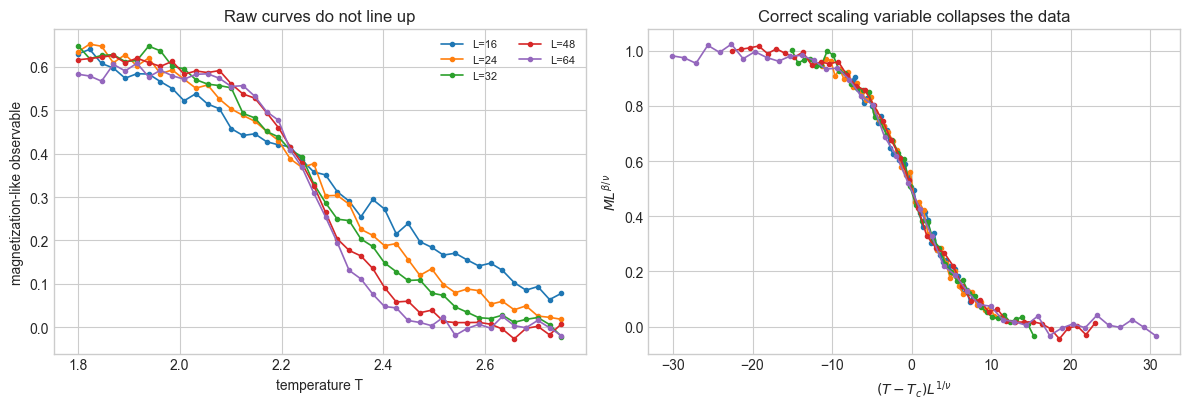

In [5]:
Tc_true = 2.27
nu_true = 1.0
beta_over_nu_true = 0.125
sizes = np.array([16, 24, 32, 48, 64])
T_grid = np.linspace(1.8, 2.75, 42)

rows = []
for L in sizes:
    for T in T_grid:
        z = (T - Tc_true) * L**(1 / nu_true)
        magnetization = L**(-beta_over_nu_true) * (0.5 + 0.5 * np.tanh(-0.14 * z))
        magnetization += rng.normal(scale=0.012)
        rows.append((L, T, magnetization))

rows = np.array(rows)
L = rows[:, 0]
T = rows[:, 1]
M = rows[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for size in sizes:
    mask = L == size
    axes[0].plot(T[mask], M[mask], marker='o', linewidth=1.2, markersize=3, label=f'L={int(size)}')
axes[0].set_xlabel('temperature T')
axes[0].set_ylabel('magnetization-like observable')
axes[0].set_title('Raw curves do not line up')
axes[0].legend(ncol=2, fontsize=8)

for size in sizes:
    mask = L == size
    z = (T[mask] - Tc_true) * size**(1 / nu_true)
    scaled_M = M[mask] * size**beta_over_nu_true
    axes[1].plot(z, scaled_M, marker='o', linewidth=1.2, markersize=3, label=f'L={int(size)}')
axes[1].set_xlabel(r'$(T - T_c)L^{1/\nu}$')
axes[1].set_ylabel(r'$M L^{\beta/\nu}$')
axes[1].set_title('Correct scaling variable collapses the data')

plt.tight_layout()
plt.show()


Best discovered nu: 1.003  (true 1.000)
Using beta/nu: 0.125
Collapse score at best point: 5.8460e-04


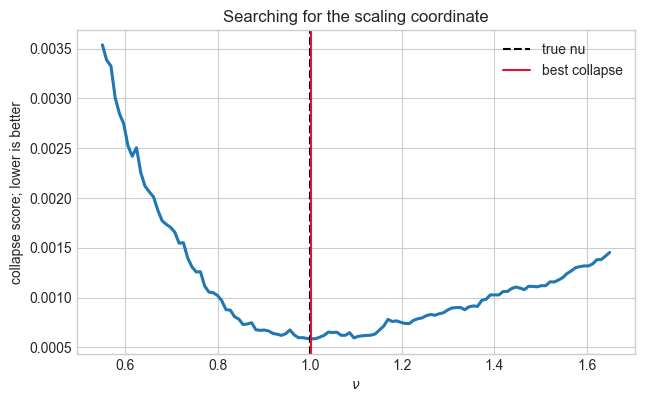

In [6]:
def collapse_score(T, L, M, Tc, nu, beta_over_nu, n_bins=24):
    z = (T - Tc) * L**(1 / nu)
    scaled_M = M * L**beta_over_nu
    bins = np.linspace(np.percentile(z, 4), np.percentile(z, 96), n_bins + 1)
    total_variance = 0.0
    used_bins = 0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (z >= lo) & (z < hi)
        if np.sum(mask) >= 4:
            total_variance += np.var(scaled_M[mask])
            used_bins += 1
    return total_variance / max(used_bins, 1)

# In real finite-size scaling analyses, some exponents may be constrained by
# theory or by independent measurements. Here we fix beta/nu and ask the
# machine to discover the coordinate exponent nu.
beta_over_nu_known = beta_over_nu_true
nu_grid = np.linspace(0.55, 1.65, 120)
scores = np.array([
    collapse_score(T, L, M, Tc_true, nu, beta_over_nu_known)
    for nu in nu_grid
])

nu_hat = nu_grid[np.argmin(scores)]

print(f'Best discovered nu: {nu_hat:.3f}  (true {nu_true:.3f})')
print(f'Using beta/nu: {beta_over_nu_known:.3f}')
print(f'Collapse score at best point: {scores.min():.4e}')

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(nu_grid, scores, linewidth=2.2)
ax.axvline(nu_true, color='black', linestyle='--', label='true nu')
ax.axvline(nu_hat, color='crimson', linestyle='-', label='best collapse')
ax.set_xlabel(r'$\nu$')
ax.set_ylabel('collapse score; lower is better')
ax.set_title('Searching for the scaling coordinate')
ax.legend()
plt.show()


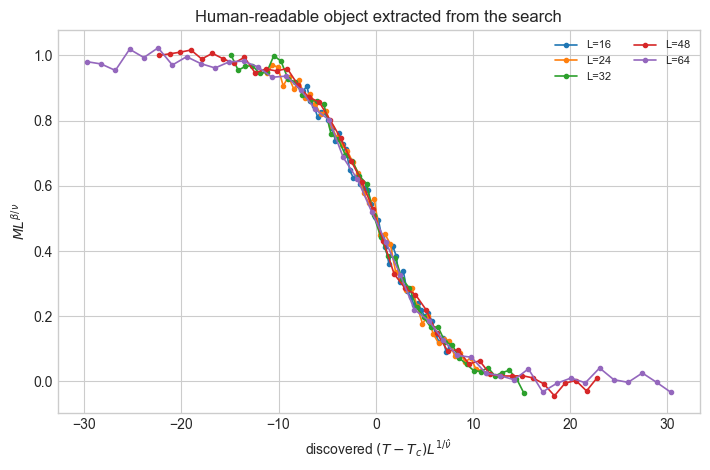

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for size in sizes:
    mask = L == size
    z_hat = (T[mask] - Tc_true) * size**(1 / nu_hat)
    scaled_M_hat = M[mask] * size**beta_over_nu_known
    ax.plot(z_hat, scaled_M_hat, marker='o', linewidth=1.2, markersize=3, label=f'L={int(size)}')

ax.set_xlabel(r'discovered $(T - T_c)L^{1/\hat{\nu}}$')
ax.set_ylabel(r'$M L^{\beta/\nu}$')
ax.set_title('Human-readable object extracted from the search')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


### <span style="color:LightGreen">What Did We Learn?</span>

The search did not just fit a curve. It proposed a dimensionless combination of variables that makes several datasets behave as one. That kind of object is much closer to physics than a raw classifier score.

This is also a warning: the result depends on the assumed form of the scaling collapse. Machine-assisted discovery is strongest when the model has enough freedom to notice a pattern but enough inductive bias to express the pattern in human language.

___<span style="color:Violet">Exercise</span>___: Let `Tc` vary in the search as well as $\nu$ and $\beta/\nu$. How sharply is the critical temperature identified?

___<span style="color:Violet">Exercise</span>___: Increase the noise level. Which parameter becomes unstable first?


## <span style="color:Orange">Methods for Learning from Trained Models</span>

Here is a compact toolbox for turning a model into a scientific hypothesis.

| Method | Question it asks | Scientific output |
|---|---|---|
| Permutation importance | What input information is necessary for performance? | Candidate important variables |
| Saliency / gradients | Where is the prediction locally sensitive? | Local response patterns |
| Counterfactuals | What minimal change flips the prediction? | Decision boundaries and failure modes |
| Latent-space probing | What physical quantities are encoded internally? | Hidden coordinates or representations |
| Surrogate models | Can a simpler model imitate the complex one? | Human-readable approximations |
| Symbolic regression | Can the relation be written as an equation? | Candidate laws or observables |
| Ablation studies | What information can be removed without losing performance? | Tests against artifacts and shortcuts |
| Out-of-distribution tests | Does the insight generalize beyond training data? | Evidence for physical robustness |

A useful rule: interpretability methods generate hypotheses; they do not certify truth by themselves.


## <span style="color:Orange">When Has the Machine Taught Us Something New?</span>

A proposed insight is stronger when it satisfies several checks:

1. <span style="color:Violet">Compression</span>: it replaces many inputs or model parameters with a simpler object.
2. <span style="color:Violet">Predictive sufficiency</span>: the object preserves most of the model's useful performance.
3. <span style="color:Violet">Robustness</span>: it survives changes in architecture, random seed, simulation settings, and detector effects.
4. <span style="color:Violet">Physical invariance</span>: it respects known symmetries or suggests a controlled symmetry breaking.
5. <span style="color:Violet">Out-of-domain generalization</span>: it works beyond the data distribution used to discover it.
6. <span style="color:Violet">Actionability</span>: it leads to a new measurement, observable, approximation, or experiment.

Rediscovering invariant mass is important because it passes many of these checks. A genuinely new machine-inspired observable should be held to the same standard.


## <span style="color:Orange">Physics Examples to Discuss</span>

### <span style="color:LightGreen">Top taggers and invariant mass</span>
Deep networks trained to identify top jets can encode physically meaningful quantities. The top-tagger interpretability paper in the prompt studies how feature importance, correlations, latent spaces, and hidden-layer activations reveal what DNN taggers learn. Invariant mass is a known quantity, so recovering it is a sanity check; deviations from mass-only behavior are where new insight may live.

### <span style="color:LightGreen">Jet images, color flow, and substructure</span>
Jet-image and particle-cloud methods made it natural to visualize radiation patterns inside jets. Sometimes the machine's advantage can be translated into observables related to prong structure, color flow, or energy correlation patterns. The hard part is separating robust QCD information from detector- or generator-specific artifacts.

### <span style="color:LightGreen">Symbolic distillation from graph networks</span>
Cranmer and collaborators trained graph neural networks with inductive biases and then applied symbolic regression to learned components. They recovered known laws in controlled systems and reported a compact formula in a cosmology simulation for dark-matter halo concentration from environmental information. This is a good example of using the neural model as a stepping stone toward an analytic expression.

### <span style="color:LightGreen">AI Feynman and equation rediscovery</span>
AI Feynman combines neural fitting with physics-inspired simplifications such as symmetry and separability. It is mainly a rediscovery benchmark, but rediscovery matters: before we trust an automated scientist on unknown physics, it should be able to recover known physics from data.


## <span style="color:Orange">Common Pitfalls</span>

- <span style="color:Violet">Shortcut learning</span>: the model uses a nuisance variable that happens to correlate with the label.
- <span style="color:Violet">Simulation leakage</span>: the model learns generator-specific artifacts rather than nature.
- <span style="color:Violet">Correlation confusion</span>: feature importance can move between correlated variables.
- <span style="color:Violet">Overinterpreted latent spaces</span>: a pretty two-dimensional embedding is not automatically a physical theory.
- <span style="color:Violet">Non-identifiability</span>: many different explanations may produce the same predictions.
- <span style="color:Violet">Selection bias</span>: an observable discovered on one benchmark may fail on another.

The cure is not one magic interpretability algorithm. The cure is repeated validation from multiple angles.


## <span style="color:Orange">Mini-Project Ideas</span>

1. Train a classifier on a toy resonance dataset with a hidden nuisance variable. Use ablations to determine whether the classifier learned the resonance or the nuisance.
2. Use symbolic regression to distill a neural-network approximation to a force law.
3. Generate two-dimensional Ising-model snapshots and see whether PCA, an autoencoder, or a classifier can recover magnetization-like order parameters.
4. Build a jet-observable search over simple functions of constituent four-vectors and compare the discovered observables to known substructure variables.
5. Study how feature-importance rankings change when two observables are highly correlated.


## <span style="color:Orange">References</span>

- PHYS 498 MLP reference style: [Introduction to Symbolic Regression](https://illinois-mlp.github.io/MachineLearningForPhysics/_sources/lectures/SymbolicRegression.html).
- Ayush Khot, Mark S. Neubauer, Avik Roy, "A detailed study of interpretability of deep neural network based top taggers," *Machine Learning: Science and Technology* 4, 035003 (2023), DOI: [10.1088/2632-2153/ace0a1](https://doi.org/10.1088/2632-2153/ace0a1). Metadata and abstract are also available through [OSTI](https://www.osti.gov/biblio/1989261) and [Illinois Experts](https://experts.illinois.edu/en/publications/a-detailed-study-of-interpretability-of-deep-neural-network-based/).
- Silviu-Marian Udrescu and Max Tegmark, "AI Feynman: A physics-inspired method for symbolic regression," *Science Advances* 6, eaay2631 (2020), [PMC article](https://pmc.ncbi.nlm.nih.gov/articles/PMC7159912/).
- Miles Cranmer et al., "Discovering Symbolic Models from Deep Learning with Inductive Biases," NeurIPS 2020, [proceedings page](https://proceedings.neurips.cc/paper/2020/hash/c9f2f917078bd2db12f23c3b413d9cba-Abstract.html).
- CERN talk record on jet images and machine learning in jet physics: [Machine learning, computer vision, and probabilistic models in jet physics](https://cds.cern.ch/record/2069153).


## <span style="color:Orange">Acknowledgments</span>

* Initial version: Mark Neubauer

© Copyright 2026